#### import the packges

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\lrban\Desktop\BTR\DATA SCIENCE\Assignments\MLR\ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


#### Renaming certain columns

In [4]:
df.rename(columns = {"Age_08_04":"Age","cc":"CC",},inplace=True) 

In [5]:
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
df.describe()

,Price,Age,KM,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


#### Finding Duplicate Records

In [7]:
df[df.duplicated()]

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [8]:
df[df["Price"] == 24950]

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
112,24950,8,13253,Diesel,116,0,2000,5,4,5,1320
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


#### we can delete the duplicate record, you cannot simply have the car ridden same distance, even if we assume there can be a further analysis.

In [9]:
df = df.drop_duplicates().reset_index().drop(columns=["index"])

In [10]:
df.shape

(1435, 11)

### Checking Null Values

In [11]:
df.isnull().sum()

Price        0
Age          0
KM           0
Fuel_Type    0
HP           0
Automatic    0
CC           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

#### Thank you for the dataset, where there are no null values

### Outlier Detctions

In [12]:

temp = []
for i in df.select_dtypes(include = "number").columns.tolist():
    #print(f"{i}: {df[i].nunique()}")
    if(df[i].nunique() > 10):
        temp.append(i)

print(f"""Choose one option :  
{", ".join(map(lambda x : str(x),temp))} """)
print()
inp = input("Enter the option here : ")
print()
q1 = df[inp].quantile(0.25)
q2 = df[inp].median()
q3 = df[inp].quantile(0.75)
iqr = q3 - q1
up_whisker = q3 + 1.5 * iqr
low_whisker = q1 - 1.5 * iqr
outliers = []
for i in df[inp]:
    if i < low_whisker or i > up_whisker:
        outliers.append(i)

print(f"{"IQR / Outliers":>25}")
print()
print(f"{"Measures":<20}    {"Values"}")
print(f"{"Q1":<20} : {q1}")
print(f"{"Q3":<20} : {q3}")
print(f"{"IQR":<21}: {q3-q1}")
print(f"{"Upper Whisker":<20} : {up_whisker}")
print(f"{"Lower Whisker":<20} : {low_whisker}")
print()
print(f"{"Total Outliers are":<21}: {len(outliers)}\n")
k = np.round(df[(df[inp] > up_whisker) | (df[inp] < low_whisker)][inp])
order = input("Enter the order you want (increasing or decreasing) : ")
print()
if(order.lower() == "decreasing"):
    k = np.sort(k)[::-1].tolist()

print(f"Outliers are : {", ".join(map(lambda x : str(x),np.round(k,5)))}")

Choose one option :  
Price, Age, KM, HP, CC, Weight 



Enter the option here :  KM



           IQR / Outliers

Measures                Values
Q1                   : 43000.0
Q3                   : 87041.5
IQR                  : 44041.5
Upper Whisker        : 153103.75
Lower Whisker        : -23062.25

Total Outliers are   : 49



Enter the order you want (increasing or decreasing) :  incresing



Outliers are : 243000, 180638, 179860, 178858, 161000, 158320, 216000, 198167, 176000, 174139, 174000, 205000, 204250, 194545, 190900, 183500, 176184, 174833, 155720, 155500, 154783, 154462, 232940, 218118, 217764, 207114, 203254, 200732, 197501, 194765, 191620, 183277, 180378, 178800, 176177, 176000, 172980, 170000, 164000, 161775, 160000, 159968, 159908, 158492, 156204, 156169, 155210, 155000, 154900


### After observing the outliers , the value of CC in the one record state 16000 instead of 1600. so we are changing it.
### Remaining all are okay

In [13]:
df[df["CC"] == 16000]["CC"]

80    16000
Name: CC, dtype: int64

In [14]:
df.loc[80,"CC"] =1600

### Statistics Summary

In [15]:
def stats_in_one_go(inp):
    
    print()
    print(f"{"Stats for":>25} {inp.upper()}")
    print()
    print("Measures of Central Tendency".center(50),"\n")
    print(f"{"Measures":<20}   {"Values":<10}")
    print(f"{"Mean":<20} : {np.round(df[inp].mean(),6):<10}")
    print(f"{"Median":<20} : {np.round(df[inp].median()):<10}")
    
    if(len(df[inp].mode())>5):
        print(f"{"Mode":<20} :Too many values for Mode, {len(df[inp].mode())} unique values")

    else:
        print(f"{"Mode":<20} : {", ".join(map(lambda x : str(x), list(df[inp].mode()))):<10}")

    print()
    print("Measures of Dispersion".center(50))
    print(f"{"Measures":<20}    {"Values"}")
    print(f"{"Variance":<20} :  {np.round(df[inp].var(),3)}")
    print(f"{"Standard Deviation":<20} :  {np.round(df[inp].std(),3)}")
    print()
    print("Skewness and Kurtosis".center(50))
    print(f"{"Measures":<20}    {"Values"}")
    print(f"{"Skewness":<20} :  {np.round(df[inp].skew(),3)}")
    print()
    if(df[inp].skew() == 0):
        print("Observation : Normally Distribution")
    elif(df[inp].skew() > 0):
        print("Observation : Right Skewed")
    else:
        print("Observation : Left Skewed")

    print()
    print(f"{"Measures":<20}    {"Values"}")
    print(f"{"Kurtosis":<20} :  {np.round(df[inp].kurt(),3)}")
    print()
    if(df[inp].kurt() > 0):
        print("Observation : Leptokurtic")
    elif(df[inp].kurt() < 0):
        print("Observation : Platykurtic")
    else:
        print("Observation : Symmetrical")

In [16]:
dtypes = list(df.select_dtypes(include = "number").columns)
print("Select an option")
print()
for i in dtypes:
    print(i)
print()
inp = input("Enter the name exactly or you can copy that, cause of your indolence : ")
stats_in_one_go(inp)

Select an option

Price
Age
KM
HP
Automatic
CC
Doors
Cylinders
Gears
Weight



Enter the name exactly or you can copy that, cause of your indolence :  KM



                Stats for KM

           Measures of Central Tendency            

Measures               Values    
Mean                 : 68571.782578
Median               : 63451.0   
Mode                 : 36000     

              Measures of Dispersion              
Measures                Values
Variance             :  1405582170.766
Standard Deviation   :  37491.095

              Skewness and Kurtosis               
Measures                Values
Skewness             :  1.017

Observation : Right Skewed

Measures                Values
Kurtosis             :  1.689

Observation : Leptokurtic


## Visualizations

### 1. Histograms

Choose one option :  
Price, Age, KM, HP, CC, Weight 



Enter the option here :  KM


If you want KDE included type 1 for "Yes" or 0 for "No" :  1


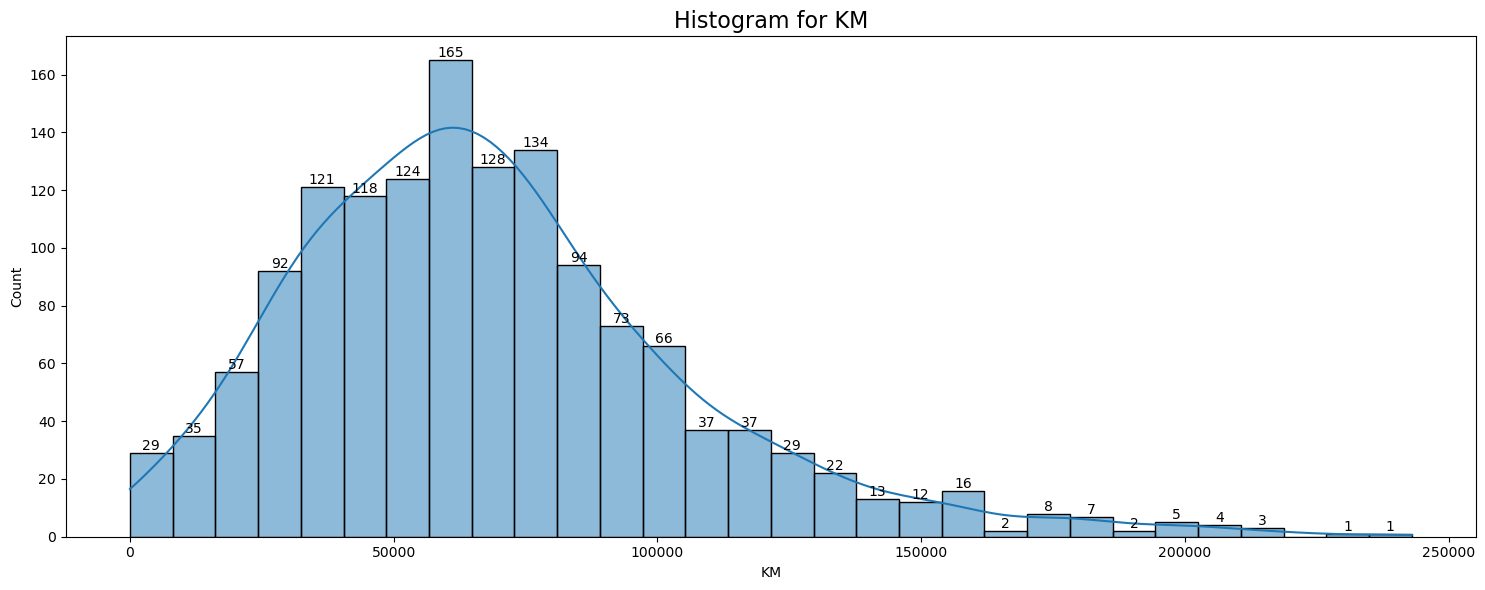

In [17]:
temp = []
for i in df.select_dtypes(include = "number").columns.tolist():
    #print(f"{i}: {df[i].nunique()}")
    if(df[i].nunique() > 10):
        temp.append(i)

print(f"""Choose one option :  
{", ".join(map(lambda x : str(x),temp))} """)
print()
inp = input("Enter the option here : ")
print()

kde_ = int(input("If you want KDE included type 1 for \"Yes\" or 0 for \"No\" : "))
print()
plt.figure(figsize = (15,6))
ax = sns.histplot(x = df[inp],
            kde = kde_,
            bins = 30
            )
for bar in ax.patches:
    height = bar.get_height()
    if(height > 0):
        ax.annotate(f"{int(height)}",
                   xy = (bar.get_x() + bar.get_width()/2,height),
                   ha = "center",
                   va = "bottom")

plt.title(f"Histogram for {inp.upper()}",fontdict ={"fontsize":16})
plt.tight_layout()
plt.show()

### 2. BarChart

Enter the catgorical column :  Automatic
Hue : Select any catgorical column other than the previous ones :  none
choose any color palette suggestions (Blues, rocket, mako, flare) :  mako


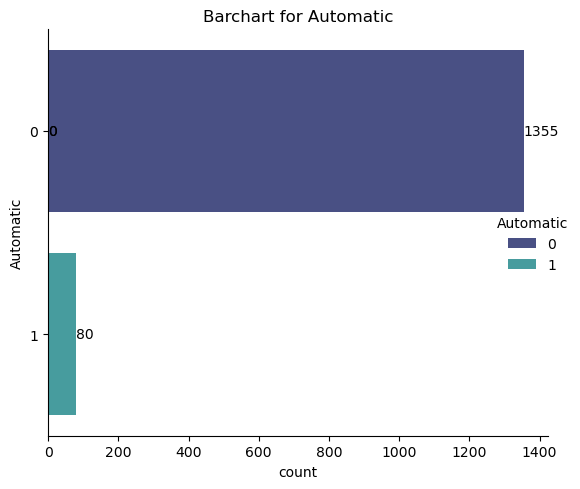

In [18]:
cat = input("Enter the catgorical column : ")
hue_ = input("Hue : Select any catgorical column other than the previous ones : ")
pal = input("choose any color palette suggestions (Blues, rocket, mako, flare) : ")
if(hue_.lower() == "none"):
    hue_ = cat

    df_bar = df[cat].value_counts().rename_axis(cat).reset_index(name = "count")
    df_bar = df_bar.sort_values(by = "count",ascending = False)
    df_bar[cat] = pd.Categorical(df_bar[cat],categories = df_bar[cat].drop_duplicates(),ordered = True)        #important    

    fg = sns.catplot(df_bar,x = "count",
           y = cat,
           kind = "bar",
           hue = hue_,
           palette = pal,
           errorbar = None)
    ax = fg.ax
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_width())}",
               xy = (bar.get_width(),bar.get_y()+bar.get_height()/2),
               ha = "left",
               va = "center")
        plt.title(f"Barchart for {cat}")
   # fg._legend.set_bbox_to_anchor((1.1,0.5))
    plt.tight_layout()
    plt.show()
else:
  
    df_bar_= df.groupby([cat,hue_])[cat].count().reset_index(name = "count")
    df_bar_ = df_bar_.sort_values(by = "count",ascending = False)
    df_bar_[cat] = pd.Categorical(df_bar_[cat],categories = df_bar_[cat].drop_duplicates(),ordered = True)
    fg = sns.catplot(df_bar_,x = df_bar_["count"],
           y = cat,
           kind = "bar",
           palette = pal,
           hue = hue_,
           errorbar = None)
    ax = fg.ax
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_width())}",
               xy = (bar.get_width(),bar.get_y()+bar.get_height()/2),
               ha = "left",
               va = "center")
    plt.title(f"Barchart for {cat} with {hue_} in terms of Count ")
    fg._legend.set_bbox_to_anchor((1.05,0.5))
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

### Scatter Plot and Correlation

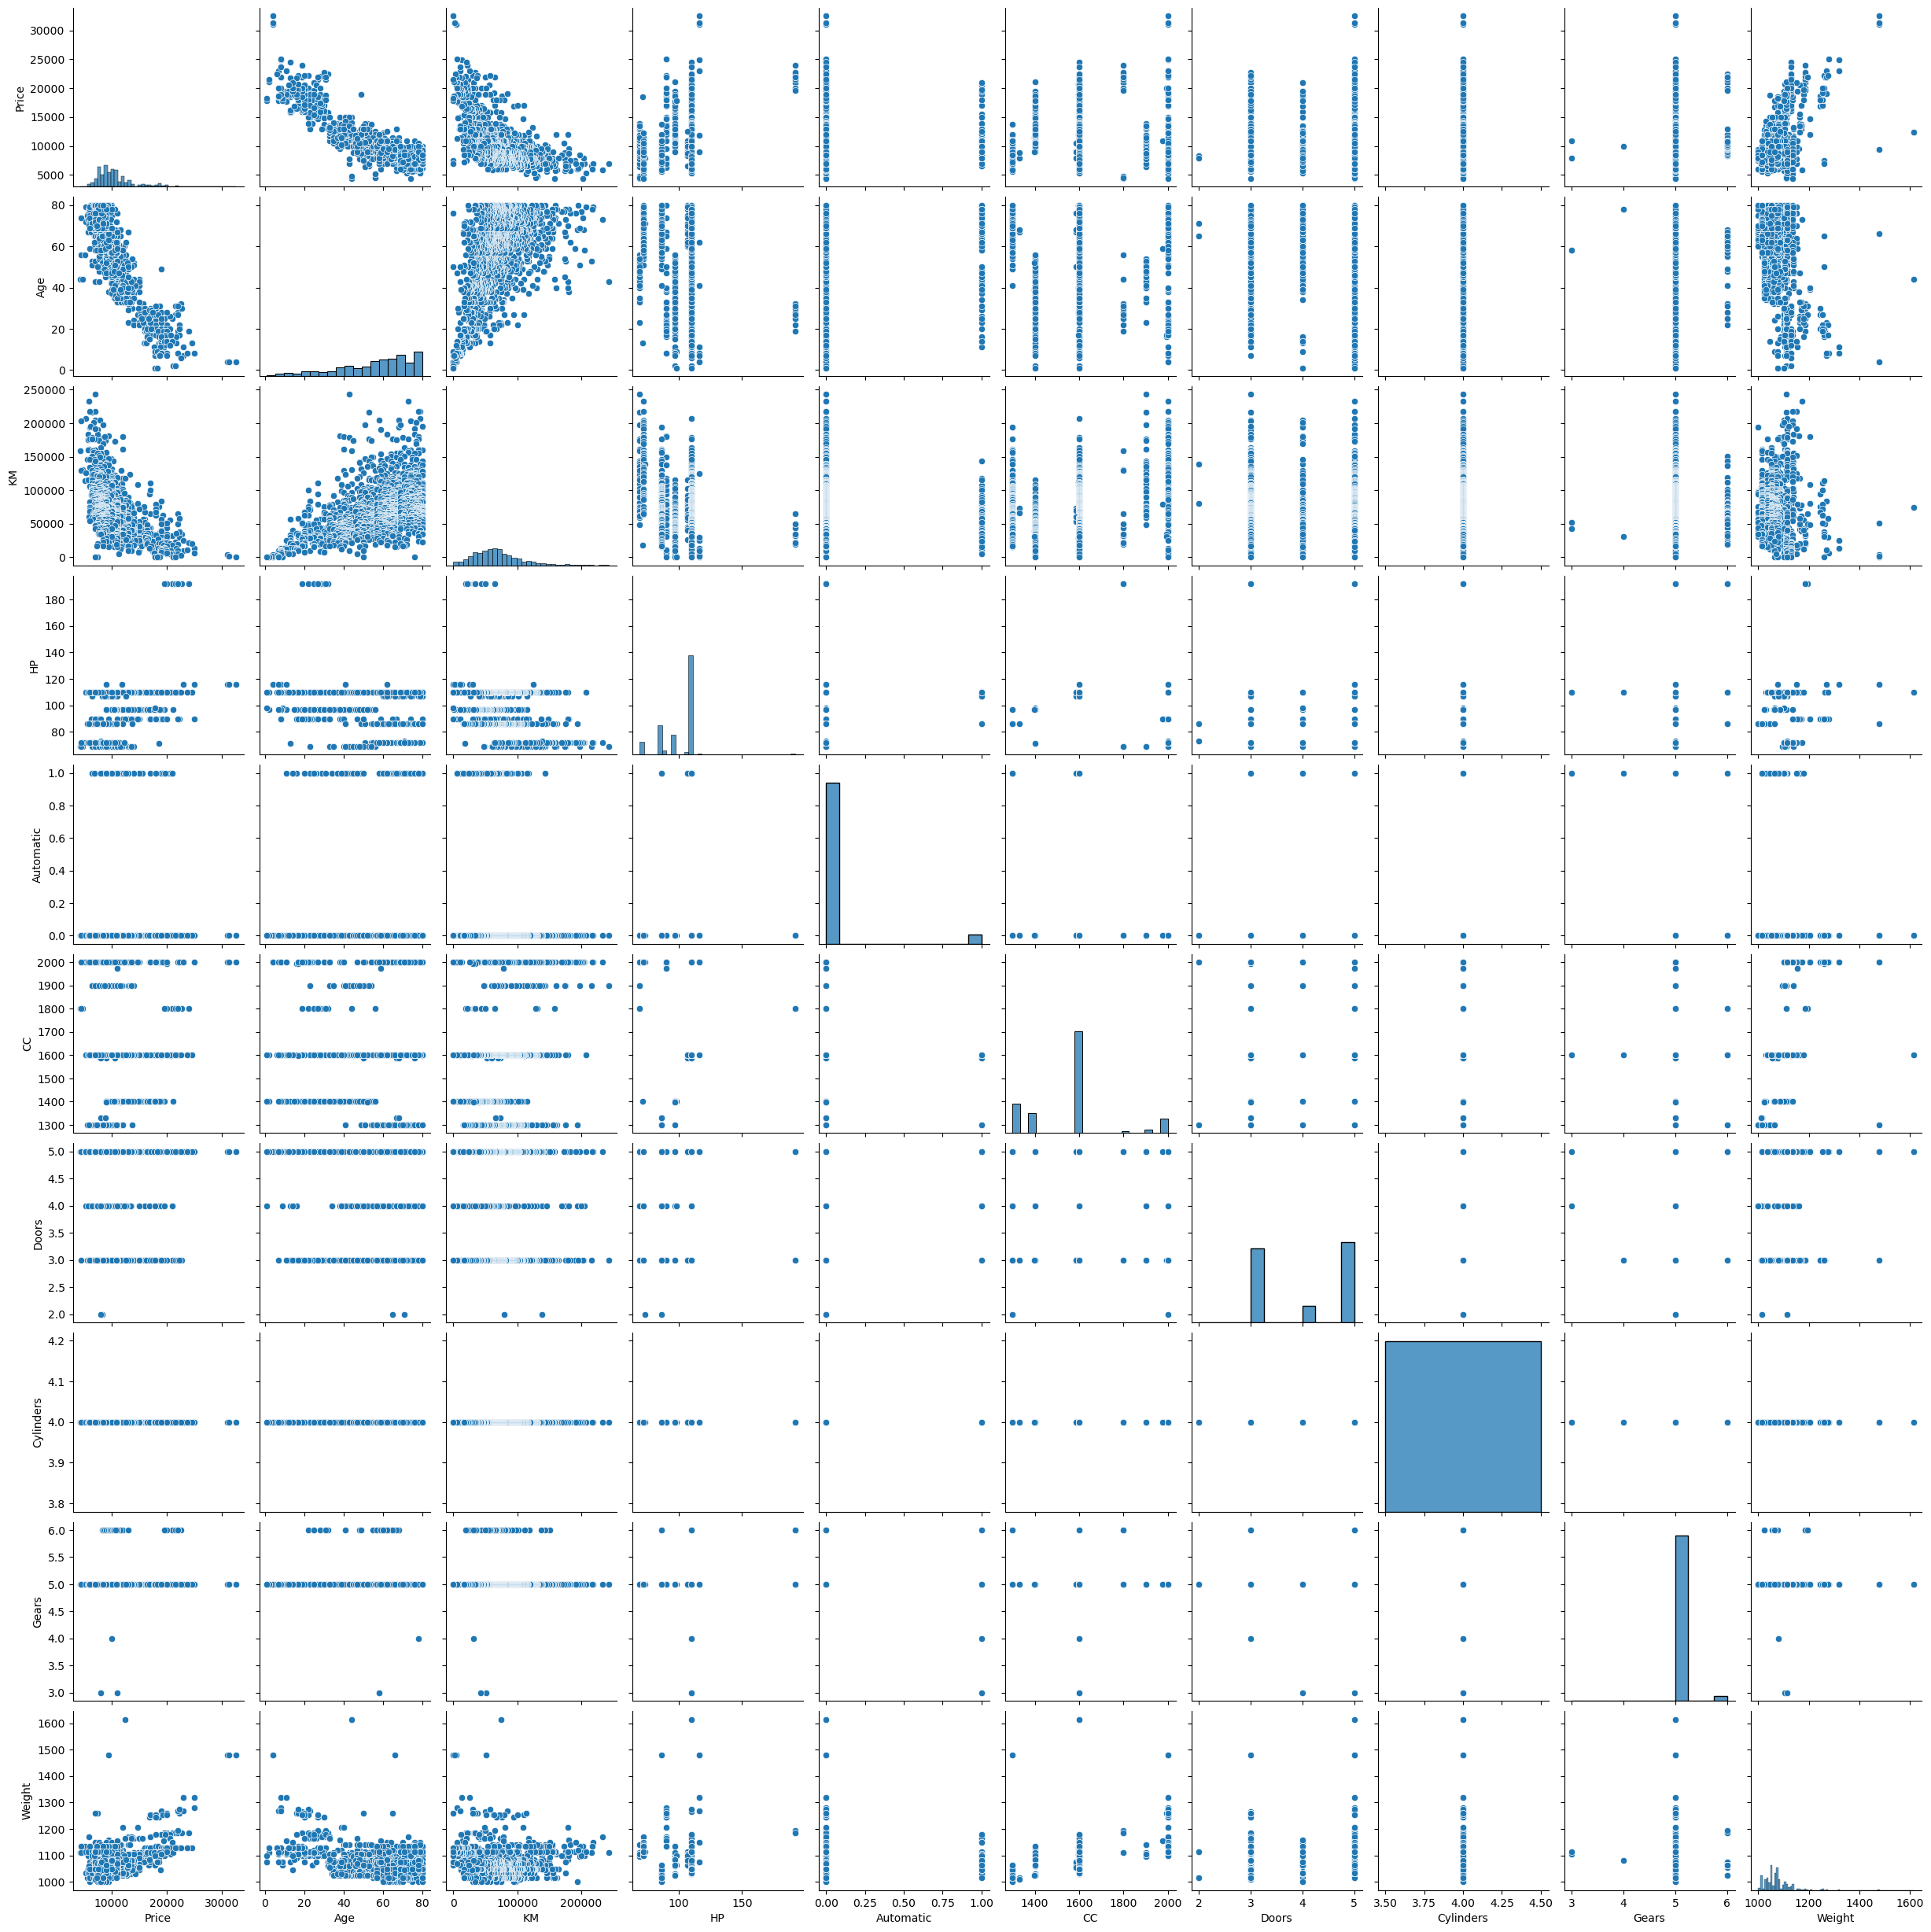

In [20]:
sns.pairplot(df)
plt.show()

In [21]:
df_corr = df.drop(columns = "Cylinders")
corr = df_corr.corr()
corr

C:\Users\lrban\AppData\Local\Temp\ipykernel_14284\4262792163.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_corr.corr()


,Price,Age,KM,HP,Automatic,CC,Doors,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.314134,0.033928,0.159897,0.183604,0.063831,0.575869
Age,-0.876273,1.000000,0.504575,-0.155293,0.031354,-0.129564,-0.146929,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,-0.332904,-0.082168,0.305331,-0.035193,0.014890,-0.023969
HP,0.314134,-0.155293,-0.332904,1.000000,0.013313,0.049430,0.091803,0.209642,0.087143
Automatic,0.033928,0.031354,-0.082168,0.013313,1.000000,-0.069060,-0.027492,-0.098582,0.058499
CC,0.159897,-0.129564,0.305331,0.049430,-0.069060,1.000000,0.125410,0.040997,0.650098
Doors,0.183604,-0.146929,-0.035193,0.091803,-0.027492,0.125410,1.000000,-0.160101,0.301734
Gears,0.063831,-0.005629,0.014890,0.209642,-0.098582,0.040997,-0.160101,1.000000,0.021238
Weight,0.575869,-0.466484,-0.023969,0.087143,0.058499,0.650098,0.301734,0.021238,1.000000


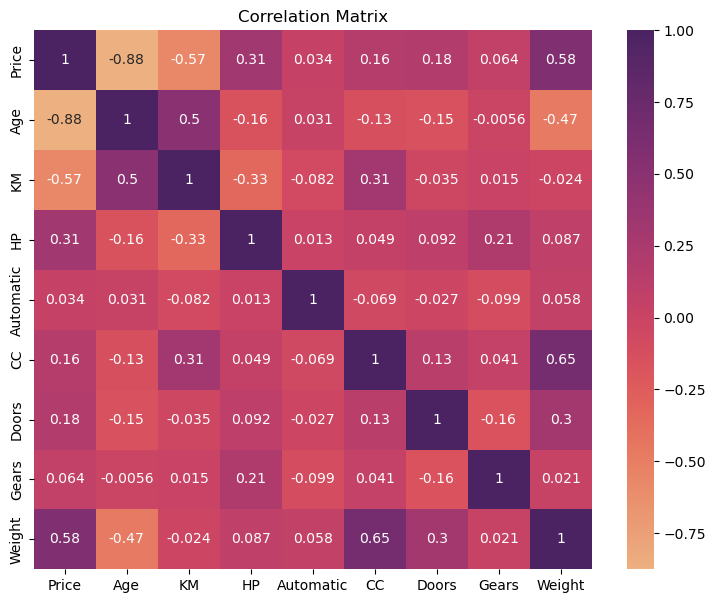

In [22]:
plt.figure(figsize = (9,7))
sns.heatmap(corr,cmap = "flare",annot = True)
plt.title("Correlation Matrix")
plt.show()

## Regression Model 1  (without encodeing only numericals)

### Split the data set
#### Dropping the categorical values and single value column namely cylinder
#### Pre process the data

#### importing required packages

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
features = df.drop(columns = ["Price","Cylinders","Fuel_Type"])
target = df[["Price"]]

In [25]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=42)
print(f"""{"x_train":<20} : {x_train.shape}
{"x_test":<20} : {x_test.shape}
{"y_train":<20} : {y_train.shape}
{"y_test":<20} : {y_test.shape}""")

x_train              : (1148, 8)
x_test               : (287, 8)
y_train              : (1148, 1)
y_test               : (287, 1)


In [26]:
model = LinearRegression()

In [27]:
model.fit(x_train,y_train)

LinearRegression()

### Evaluate the model
#### import the packages

In [28]:
from sklearn.metrics import mean_squared_error,r2_score

In [29]:
y_train_pred = model.predict(x_train)

In [30]:
train_mse = mean_squared_error(y_train,y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_train_pred)
print(f"""Train MSE : {np.round(train_mse,2)}
Train RMSE : {np.round(train_rmse,2)}
Train R2 : {np.round(train_r2)}""")

Train MSE : 1688361.84
Train RMSE : 1299.37
Train R2 : 1.0


### Testing Data

In [31]:
y_test_pred = model.predict(x_test)

In [32]:
test_mse = mean_squared_error(y_test,y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test,y_test_pred)
print(f"""Train MSE : {np.round(test_mse,2)}
Train RMSE : {np.round(test_rmse,2)}
Train R2 : {np.round(test_r2,2)}""")

Train MSE : 2137113.63
Train RMSE : 1461.89
Train R2 : 0.82


## Regression Model 2 : with Categorical Variables
### Columns : Fule Type is in categorical datatype, converting it to numerical

In [33]:
df_dummies = pd.get_dummies(df)
df_dummies

,Price,Age,KM,HP,Automatic,CC,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,86,0,1300,3,4,5,1025,0,0,1
1431,10845,72,19000,86,0,1300,3,4,5,1015,0,0,1
1432,8500,71,17016,86,0,1300,3,4,5,1015,0,0,1
1433,7250,70,16916,86,0,1300,3,4,5,1015,0,0,1


In [34]:
features = df_dummies.drop(columns = ["Price","Cylinders"])
target = df_dummies[["Price"]]

In [35]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=42)
print(f"""{"x_train":<20} : {x_train.shape}
{"x_test":<20} : {x_test.shape}
{"y_train":<20} : {y_train.shape}
{"y_test":<20} : {y_test.shape}""")

x_train              : (1148, 11)
x_test               : (287, 11)
y_train              : (1148, 1)
y_test               : (287, 1)


### Standardization

#### It is best for Linear Regression , because it is less affected by the outliers

#### Import the packages

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_train_scaled

,Age,KM,HP,Automatic,CC,Doors,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,1.186756,1.059947,0.567622,-0.234834,0.172327,1.020018,-0.142124,-0.043336,-0.107022,-0.351123,0.371161
1,0.330845,-0.262703,-1.029185,-0.234834,-1.427088,1.020018,-0.142124,-0.735395,-0.107022,-0.351123,0.371161
2,0.812295,0.559850,-1.029185,-0.234834,-1.427088,1.020018,-0.142124,-0.735395,-0.107022,-0.351123,0.371161
3,-0.632054,-0.814177,0.567622,-0.234834,0.172327,1.020018,-0.142124,0.154396,-0.107022,-0.351123,0.371161
4,1.026273,0.863857,0.567622,-0.234834,0.172327,1.020018,-0.142124,-0.043336,-0.107022,-0.351123,0.371161
...,...,...,...,...,...,...,...,...,...,...,...
1143,1.026273,1.487092,0.567622,-0.234834,0.172327,-1.082281,-0.142124,-0.438798,-0.107022,-0.351123,0.371161
1144,1.026273,1.000045,0.567622,-0.234834,0.172327,-1.082281,-0.142124,-0.438798,-0.107022,-0.351123,0.371161
1145,1.293745,0.060363,0.567622,-0.234834,0.172327,-0.031132,-0.142124,-0.735395,-0.107022,-0.351123,0.371161
1146,0.491328,-0.121486,0.567622,-0.234834,0.172327,1.020018,-0.142124,-0.043336,-0.107022,-0.351123,0.371161


In [38]:
y_train

,Price
1127,7500
898,9500
1187,7950
310,13995
1144,6450
...,...
1095,7900
1130,9950
1294,7500
860,10950


### Build the model and Train it

In [39]:
model = LinearRegression()
model

LinearRegression()

In [40]:
model.fit(x_train_scaled,y_train)

LinearRegression()

### Evaluate the model

#### import the required packages

In [41]:
from sklearn.metrics import r2_score,mean_squared_error

In [42]:
y_train_pred = model.predict(x_train_scaled)
y_train_pred

array([[7522.34239021],
       [9245.12525658],
       [7690.04002075],
       ...,
       [7017.35822039],
       [9764.69479426],
       [8260.90838925]])

In [43]:
train_mse = mean_squared_error(y_train,y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_train_pred)
print(f"""Train MSE :{np.round(train_mse,2)}
Train RMSE : {np.round(train_rmse,2)}
Train R2 : {np.round(train_r2,2)}""")


Train MSE :1671697.75
Train RMSE : 1292.94
Train R2 : 0.87


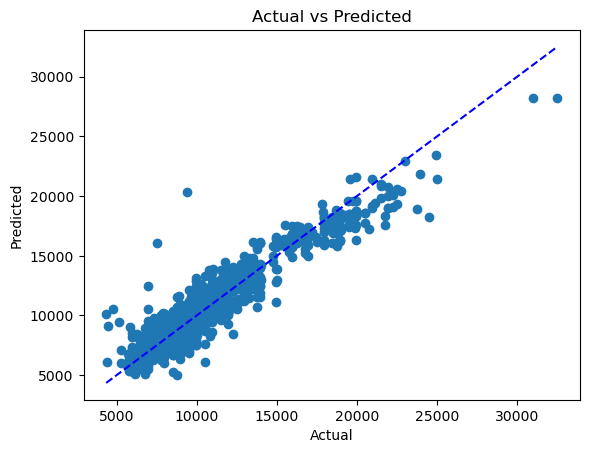

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "b--")
plt.show()


### Predict the TESTING data

In [45]:
x_test_scaled = pd.DataFrame(x_test_scaled,columns = x_test.columns)
x_test_scaled.head()

,Age,KM,HP,Automatic,CC,Doors,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,0.170362,0.296739,0.567622,-0.234834,0.172327,-1.082281,5.484042,-0.142201,-0.107022,-0.351123,0.371161
1,0.330845,-0.117065,0.567622,-0.234834,0.172327,1.020018,-0.142124,0.055530,-0.107022,-0.351123,0.371161
2,0.170362,1.608854,-1.960656,-0.234834,2.304882,-0.031132,-0.142124,1.241918,-0.107022,2.848001,-2.694252
3,0.705306,-0.699324,0.567622,-0.234834,0.172327,-1.082281,-0.142124,-0.438798,-0.107022,-0.351123,0.371161
4,0.491328,-0.587780,-1.029185,-0.234834,-1.427088,-1.082281,-0.142124,-1.130857,-0.107022,-0.351123,0.371161


In [46]:
y_test.head()

,Price
752,9950
857,7995
629,7500
1411,9950
974,8950


In [47]:
y_test_pred = model.predict(x_test_scaled)

In [48]:
test_mse = mean_squared_error(y_test,y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2score = r2_score(y_test,y_test_pred)
print(f"""Test MSE : {np.round(test_mse,2)}
Test RMSE : {np.round(test_rmse,2)}
R-2  Score : {np.round(test_r2score,2)} """)

Test MSE : 2028993.18
Test RMSE : 1424.43
R-2  Score : 0.83 


In [49]:
model.coef_

array([[-2240.11992854,  -579.39134867,   673.02015058,    73.16538056,
         -630.34782754,   -47.49955597,    62.36453902,  1292.36857273,
         -141.10699549,   151.51651589,   -99.41530982]])

In [50]:
model.intercept_

array([10727.04616725])

## Model 3 : calculating VIF (to determine which feature can be considered for final model)

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant #better , it will tell what Y is whem all the features are 0

In [52]:
df_dummies = pd.get_dummies(df)  #which is perfect for multi collinearity, one column can find the other columns
df_dummies = df_dummies.drop(columns = "Fuel_Type_Diesel")

In [53]:
df_dummies = add_constant(df_dummies)
df_dummies.shape

(1435, 12)

In [54]:
vif = pd.DataFrame()
vif["features"] = df_dummies.columns
vif["VIF"] = [variance_inflation_factor(df_dummies.values,i) for i in range(df_dummies.shape[1])]
vif

,features,VIF
0,Price,7.606427
1,Age,4.931603
2,KM,2.245187
3,HP,6.885443
4,Automatic,1.090588
5,CC,9.075778
6,Doors,1.241444
7,Cylinders,2712.854192
8,Gears,1.134148
9,Weight,3.911496


#### From the above vif calculations , cylinders can be dropped, although petrol_fueltype is also crossing 10 , but let it be

In [55]:
df_dummies = df_dummies.drop(columns = "Cylinders")
df_dummies.head()

,Price,Age,KM,HP,Automatic,CC,Doors,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,0,0
1,13750,23,72937,90,0,2000,3,5,1165,0,0
2,13950,24,41711,90,0,2000,3,5,1165,0,0
3,14950,26,48000,90,0,2000,3,5,1165,0,0
4,13750,30,38500,90,0,2000,3,5,1170,0,0


### SPLIT the Data

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
features = df_dummies.drop(columns = "Price")
target = df_dummies["Price"]
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size = 0.2,random_state = 42)

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled = pd.DataFrame(x_train_scaled,columns = features.columns)
x_test_scaled = scaler.transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled,columns = features.columns)

In [59]:
x_test_scaled.head()

,Age,KM,HP,Automatic,CC,Doors,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Petrol
0,0.170362,0.296739,0.567622,-0.234834,0.172327,-1.082281,5.484042,-0.142201,-0.107022,0.371161
1,0.330845,-0.117065,0.567622,-0.234834,0.172327,1.020018,-0.142124,0.055530,-0.107022,0.371161
2,0.170362,1.608854,-1.960656,-0.234834,2.304882,-0.031132,-0.142124,1.241918,-0.107022,-2.694252
3,0.705306,-0.699324,0.567622,-0.234834,0.172327,-1.082281,-0.142124,-0.438798,-0.107022,0.371161
4,0.491328,-0.587780,-1.029185,-0.234834,-1.427088,-1.082281,-0.142124,-1.130857,-0.107022,0.371161


In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

### Predict the Model

In [62]:
from sklearn.metrics import mean_squared_error,r2_score

In [63]:
y_pred_train = model.predict(x_train_scaled)

In [64]:
train_mse = mean_squared_error(y_train,y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_pred_train)
print(f"""{"Train MSE":<20} : {np.round(train_mse,2)}
{"Train RMSE":<20} : {np.round(train_rmse,2)}
{"Train R2 Score":<20} : {np.round(train_r2,2)}""")

Train MSE            : 1671697.75
Train RMSE           : 1292.94
Train R2 Score       : 0.87



### Testing Data

In [65]:
y_pred_test = model.predict(x_test_scaled)

In [66]:
test_mse = mean_squared_error(y_test,y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test,y_pred_test)
print(f"""{"Test MSE":<20} : {np.round(test_mse,2)}
{"Test RMSE":<20} : {np.round(test_rmse,2)}
{"Test R2 Score":<20} : {np.round(test_r2,2)}""")

Test MSE             : 2028993.18
Test RMSE            : 1424.43
Test R2 Score        : 0.83


## Applying Regularizations

#### 1. Lasso

#### we know the latest regression intercepts(aka coefficients)

In [67]:
coef = pd.DataFrame()

In [68]:
coef["Features"] = x_train_scaled.columns
coef["Linear_coeffcients"] = model.coef_
coef.head()

,Features,Linear_coeffcients
0,Age,-2240.119929
1,KM,-579.391349
2,HP,673.020151
3,Automatic,73.165381
4,CC,-630.347828


#### import the required packages

In [69]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [70]:
lasso = Lasso(alpha = 6) # alpha is a limiter , controls the coeffcients, alpha ranges (0 to 1/0)

In [71]:
lasso.fit(x_train_scaled,y_train)

Lasso(alpha=6)

In [72]:
y_pred_train = lasso.predict(x_train_scaled)

### Test the model

In [73]:
train_mse = mean_squared_error(y_train,y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_pred_train)
print(f"""{"Train MSE":<20} : {np.round(train_mse,2)}
{"Train RMSE":<20} : {np.round(train_rmse,2)}
{"Train R2 Score":<20} : {np.round(train_r2,2)}""")

Train MSE            : 1675276.05
Train RMSE           : 1294.32
Train R2 Score       : 0.87


In [74]:
lasso.coef_

array([-2243.55163968,  -574.64681362,   537.32488656,    59.53569225,
        -467.58873742,   -54.1808555 ,    63.21405564,  1322.399361  ,
        -115.50294807,   -21.57702594])

### Testing data

In [75]:
y_pred_test = lasso.predict(x_test_scaled)

In [76]:
test_mse = mean_squared_error(y_test,y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test,y_pred_test)
print(f"""{"Test MSE":<20} : {np.round(test_mse,2)}
{"Test RMSE":<20} : {np.round(test_rmse,2)}
{"Test R2 Score":<20} : {np.round(test_r2,2)}""")

Test MSE             : 2076565.7
Test RMSE            : 1441.03
Test R2 Score        : 0.83


### For Lasso there is slighly improvment in the results when we set the alpha value to 100

In [77]:
coef["Lasso"] = lasso.coef_

In [78]:
coef

,Features,Linear_coeffcients,Lasso
0,Age,-2240.119929,-2243.551640
1,KM,-579.391349,-574.646814
2,HP,673.020151,537.324887
3,Automatic,73.165381,59.535692
4,CC,-630.347828,-467.588737
5,Doors,-47.499556,-54.180855
6,Gears,62.364539,63.214056
7,Weight,1292.368573,1322.399361
8,Fuel_Type_CNG,-192.395361,-115.502948
9,Fuel_Type_Petrol,-257.540929,-21.577026


#### We can observe there is a change(reduction) in coeffcients.
#### More the alpha value , more the restrictions, chance of coefficints being zero is high

## 2.Ridge

In [79]:
ridge = Ridge(alpha = 150)

In [80]:
ridge.fit(x_train_scaled,y_train)

Ridge(alpha=150)

In [81]:
y_pred_train = ridge.predict(x_train_scaled)

### Test the train Data

In [82]:
train_mse = mean_squared_error(y_train,y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_pred_train)
print(f"""{"Train MSE":<20} : {np.round(train_mse,2)}
{"Train RMSE":<20} : {np.round(train_rmse,2)}
{"Train R2 Score":<20} : {np.round(train_r2,2)}""")

Train MSE            : 1773153.9
Train RMSE           : 1331.6
Train R2 Score       : 0.87


In [83]:
y_pred_test = ridge.predict(x_test_scaled)

### Test the Test Data

In [84]:
test_mse = mean_squared_error(y_test,y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test,y_pred_test)
print(f"""{"Test MSE":<20} : {np.round(test_mse,2)}
{"Test RMSE":<20} : {np.round(test_rmse,2)}
{"Test R2 Score":<20} : {np.round(test_r2,2)}""")

Test MSE             : 1974185.77
Test RMSE            : 1405.06
Test R2 Score        : 0.84


In [85]:
coef["Ridge"] = ridge.coef_
coef

,Features,Linear_coeffcients,Lasso,Ridge
0,Age,-2240.119929,-2243.551640,-1982.805053
1,KM,-579.391349,-574.646814,-715.745310
2,HP,673.020151,537.324887,447.642919
3,Automatic,73.165381,59.535692,69.585134
4,CC,-630.347828,-467.588737,-223.616269
5,Doors,-47.499556,-54.180855,3.549565
6,Gears,62.364539,63.214056,80.042995
7,Weight,1292.368573,1322.399361,1144.135589
8,Fuel_Type_CNG,-192.395361,-115.502948,-74.045754
9,Fuel_Type_Petrol,-257.540929,-21.577026,18.095891


## 3. Elastic Net

In [86]:
elasticnet = ElasticNet(alpha = 0.2,l1_ratio = 0.5)

#### Model on Training Data

In [87]:
elasticnet.fit(x_train_scaled,y_train)

ElasticNet(alpha=0.2)

In [88]:
y_pred_train = elasticnet.predict(x_train_scaled)

### Testing on training data

In [89]:
train_mse = mean_squared_error(y_train,y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_pred_train)
print(f"""{"Train MSE":<20} : {np.round(train_mse,2)}
{"Train RMSE":<20} : {np.round(train_rmse,2)}
{"Train R2 Score":<20} : {np.round(train_r2,2)}""")

Train MSE            : 1738632.03
Train RMSE           : 1318.57
Train R2 Score       : 0.87


#### Predicting the testing data

In [90]:
y_pred_test = elasticnet.predict(x_test_scaled)

#### Testing the test data

In [91]:
test_mse = mean_squared_error(y_test,y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test,y_pred_test)
print(f"""{"Test MSE":<20} : {np.round(test_mse,2)}
{"Test RMSE":<20} : {np.round(test_rmse,2)}
{"Test R2 Score":<20} : {np.round(test_r2,2)}""")

Test MSE             : 1977153.77
Test RMSE            : 1406.11
Test R2 Score        : 0.84


In [92]:
coef["ElasticNet"] = elasticnet.coef_

In [93]:
coef

,Features,Linear_coeffcients,Lasso,Ridge,ElasticNet
0,Age,-2240.119929,-2243.551640,-1982.805053,-2035.978830
1,KM,-579.391349,-574.646814,-715.745310,-695.763941
2,HP,673.020151,537.324887,447.642919,463.063935
3,Automatic,73.165381,59.535692,69.585134,69.077425
4,CC,-630.347828,-467.588737,-223.616269,-266.042593
5,Doors,-47.499556,-54.180855,3.549565,-8.045383
6,Gears,62.364539,63.214056,80.042995,78.585367
7,Weight,1292.368573,1322.399361,1144.135589,1178.198594
8,Fuel_Type_CNG,-192.395361,-115.502948,-74.045754,-81.350762
9,Fuel_Type_Petrol,-257.540929,-21.577026,18.095891,11.141832


### One can observe what's really happening behind the scenes. It depends on the alpha value, 
### Based on the alpha value the coeffcients gets reduced

## GridSearch

#### It is technique for finding optimal parameter values of hyperparameters, simply hyper parameter tuning

#### Import the required package

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [107]:
pipe = Pipeline([("model",Ridge())])
grid_params = [{"model":[Lasso()],
               "model__alpha":np.logspace(-4,4,1000)},
               {"model" : [Ridge()],
               "model__alpha":np.logspace(-4,4,1000)},
               {"model":[ElasticNet()],
               "model__alpha":np.logspace(-4,4,1000),
               "model__l1_ratio":np.linspace(0.1,0.9,9)}
              ]
grid = GridSearchCV(estimator = pipe,param_grid=grid_params)
grid.fit(x_train_scaled,y_train)
print(grid.best_estimator_)
print(grid.best_params_)
print(grid.best_score_)

Pipeline(steps=[('model', ElasticNet(alpha=0.21445260759716675, l1_ratio=0.8))])
{'model': ElasticNet(), 'model__alpha': 0.21445260759716675, 'model__l1_ratio': 0.8}
0.8598883443077909


## Concluson :
#### The model is predicting the data with an R2 score of 0.84, which will be 84 percent.
#### In order to deal with multi-collinearity, VIF (variance inflation factor) is used. Depends on the score,  we drop the column with high VIF score
#### Based on the grid search, The Best Regularization will be Elastic Net 
#### Best alpha values will be 0.21
#### Best L1 Ratio will be 0.8